In [ ]:
# Step 1 : Install Ultralytics
! pip install Ultralytics --upgrade -q

In [ ]:
# Step2 : Load Model
from ultralytics import YOLO
model = YOLO("yolov9e.pt")


In [ ]:
# See the model parameter
model.info(verbose = True)

YOLOv9e summary: 721 layers, 58,206,592 parameters, 0 gradients, 193.0 GFLOPs


(721, 58206592, 0, 193.01565439999996)

In [ ]:
# See full architecture
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Identity()
    (1): Conv(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): Conv(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (3): RepNCSPELAN4(
      (cv1): Conv(
        (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Sequential(
        (0): RepCSP(
          (cv1): Conv(
            (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): BatchNorm2d(32, eps=0.001, momentum


0: 416x640 11 cars, 6 trucks, 75.1ms
Speed: 3.0ms preprocess, 75.1ms inference, 1.6ms postprocess per image at shape (1, 3, 416, 640)


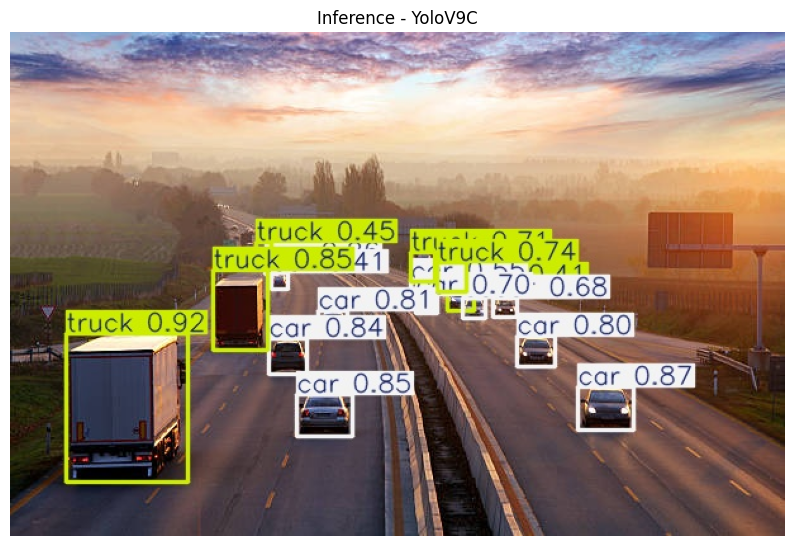

In [34]:
# import cv2 library for nececery
import cv2
import matplotlib.pyplot as plt
image_path = "/content/car image.jpg"
image = cv2.imread(image_path)

result = model(image)


# using for loop save the image as result.jpg
for r in result:
  r.save(filename = "result.jpg")


# result.jpg --> store the image
img_result = cv2.imread("result.jpg")
# convert the image RGB format
img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)
plt.figure(figsize = (10,8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Inference - YoloV9C")
plt.show()
